In [8]:
# ============================================
# 0. Configuración inicial | Initial Setup
# ============================================
# 🇲🇽 Español: Este bloque carga el dataset limpio desde la carpeta 'data/cleaned'
# y lo prepara para el análisis exploratorio.
# 🌍 English: This block loads the cleaned dataset from 'data/cleaned'
# and prepares it for exploratory analysis.

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Definir rutas relativas al repositorio
DATA_CLEAN = "https://raw.githubusercontent.com/Pablo-Santana-MX/lettuce-data-quality/main/data/raw/lettuce_growth_raw.csv"
# Cargar dataset limpio
df = pd.read_csv(DATA_CLEAN, encoding="latin1")

# ============================================
# Normalización de nombres de columnas | Column Name Normalization
# ============================================
# 🇲🇽 Español: Renombrar columnas para eliminar espacios y símbolos,
# dejando nombres consistentes y fáciles de usar en análisis.
# 🌍 English: Rename columns to remove spaces and symbols,
# creating consistent names for analysis.

df.rename(columns={
    "Plant_ID": "plant_id",
    "Date": "date",
    "Temperature (°C)": "temperature_c",
    "Humidity (%)": "humidity_percent",
    "TDS Value (ppm)": "tds_ppm",
    "pH Level": "ph_level",
    "Growth Days": "growth_days"
}, inplace=True)
# ============================================
# Clasificación de Humedad | Humidity Classification
# ============================================
# 🇲🇽 Español: Crear una columna categórica que clasifique la humedad
# en tres niveles: Low, Medium, High.
# 🌍 English: Create a categorical column that classifies humidity
# into three levels: Low, Medium, High.

df['humidity_class'] = pd.cut(
    df['humidity_percent'],
    bins=[0, 55, 70, 100],
    labels=['Low', 'Medium', 'High']
)

print("✅ Columna 'humidity_class' creada correctamente")
print(df[['humidity_percent','humidity_class']].head())

print("✅ Columnas normalizadas:\n", df.columns)


# Vista rápida del DataFrame
print("Primeras filas del dataset:")
print(df.head())

print("\nInformación general del dataset:")
print(df.info())


✅ Columna 'humidity_class' creada correctamente
   humidity_percent humidity_class
0                53            Low
1                53            Low
2                59         Medium
3                68         Medium
4                74           High
✅ Columnas normalizadas:
 Index(['plant_id', 'date', 'temperature_c', 'humidity_percent', 'tds_ppm',
       'ph_level', 'growth_days', 'humidity_class'],
      dtype='object')
Primeras filas del dataset:
   plant_id        date  temperature_c  humidity_percent  tds_ppm  ph_level  \
0         1  08/03/2023           33.4                53      582       6.4   
1         1  08/04/2023           33.5                53      451       6.1   
2         1  08/05/2023           33.4                59      678       6.4   
3         1  08/06/2023           33.4                68      420       6.4   
4         1  08/07/2023           33.4                74      637       6.5   

   growth_days humidity_class  
0            1            Low  

          plant_id  temperature_c  humidity_percent      tds_ppm     ph_level  \
count  3169.000000    3169.000000       3169.000000  3169.000000  3169.000000   
mean     35.441780      28.142222         64.873462   598.045440     6.399211   
std      20.243433       4.670521          8.988985   115.713047     0.234418   
min       1.000000      18.000000         50.000000   400.000000     6.000000   
25%      18.000000      23.600000         57.000000   498.000000     6.200000   
50%      35.000000      30.200000         65.000000   593.000000     6.400000   
75%      53.000000      31.500000         73.000000   699.000000     6.600000   
max      70.000000      33.500000         80.000000   800.000000     6.800000   

       growth_days  
count  3169.000000  
mean     23.140107  
std      13.075415  
min       1.000000  
25%      12.000000  
50%      23.000000  
75%      34.000000  
max      48.000000  


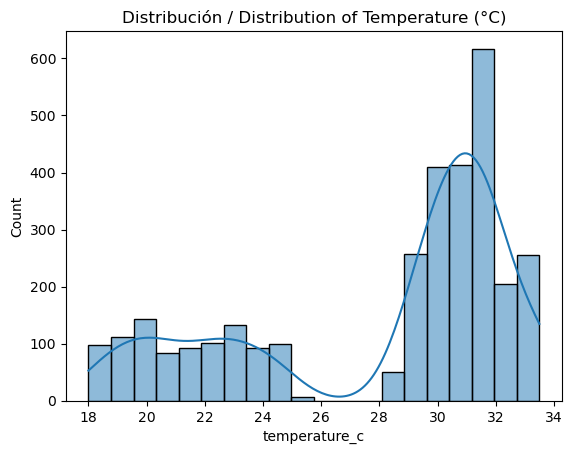

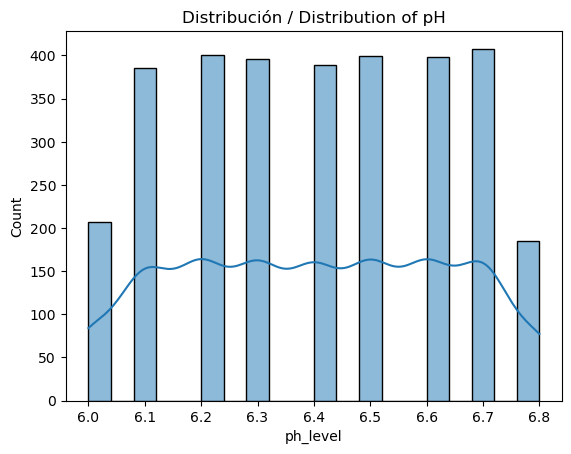

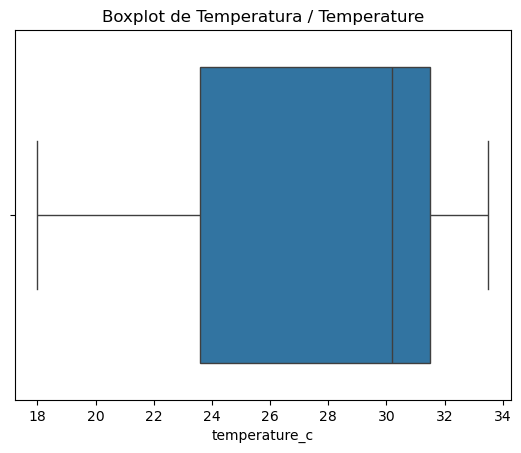

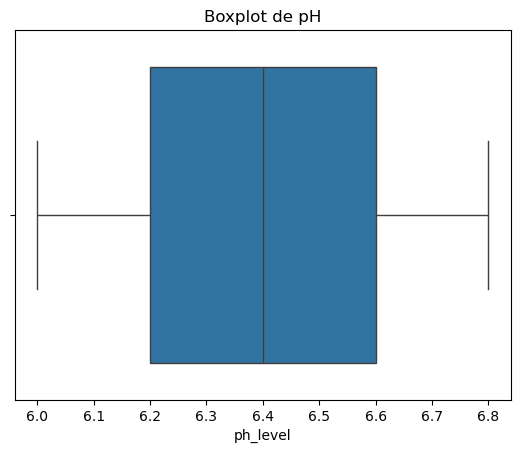

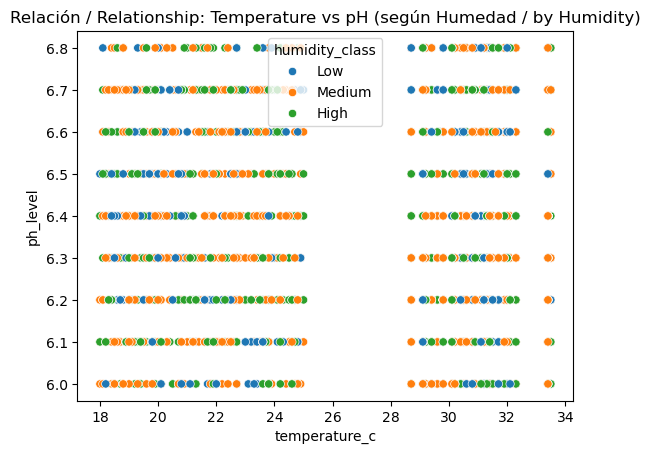

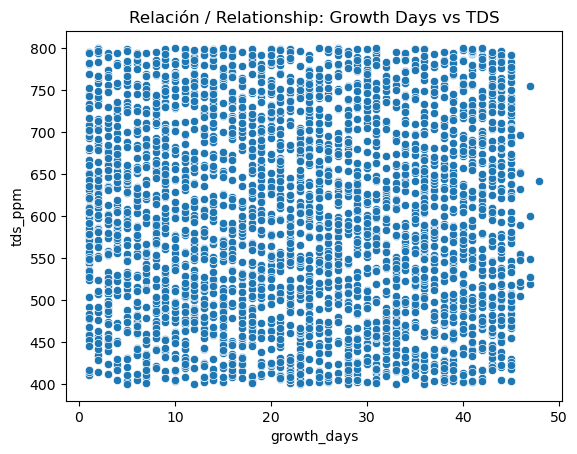

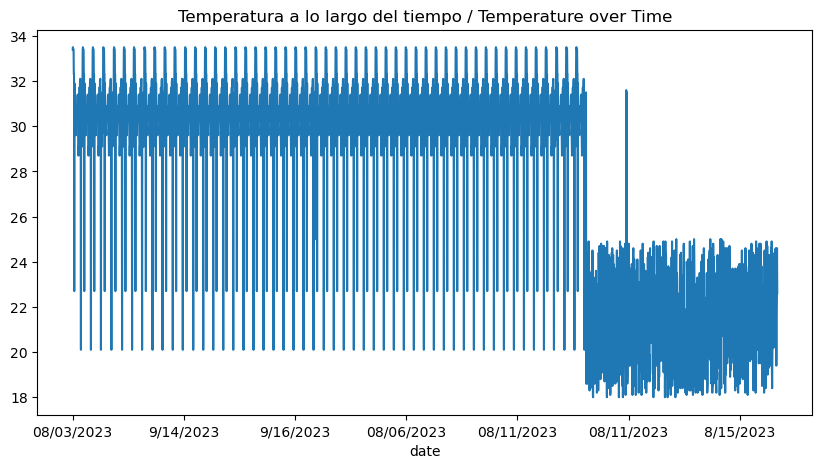

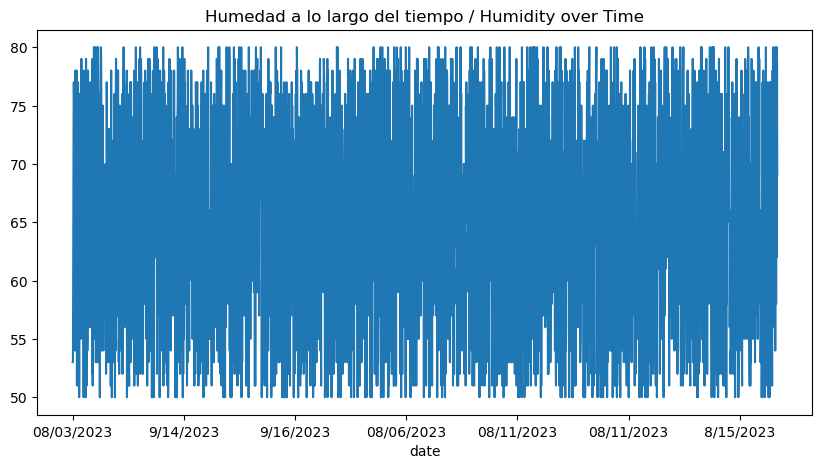

In [9]:
# ============================================
# 1. Estadísticas Descriptivas | Descriptive Statistics
# ============================================
# 🇲🇽 Español: Obtener una visión general de las variables numéricas,
# incluyendo medidas de tendencia central y dispersión.
# 🌍 English: Get an overview of numerical variables,
# including measures of central tendency and dispersion.
print(df.describe())

# ============================================
# 2. Distribución de Variables | Variable Distribution
# ============================================
# 🇲🇽 Español: Visualizar cómo se distribuyen los valores para detectar sesgos,
# concentraciones y posibles valores extremos.
# 🌍 English: Visualize how values are distributed to detect skewness,
# concentrations, and possible extreme values.
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['temperature_c'], bins=20, kde=True)
plt.title("Distribución / Distribution of Temperature (°C)")
plt.show()

sns.histplot(df['ph_level'], bins=20, kde=True)
plt.title("Distribución / Distribution of pH")
plt.show()

# ============================================
# 3. Boxplots para Outliers | Boxplots for Outliers
# ============================================
# 🇲🇽 Español: Identificar valores atípicos y rangos óptimos.
# 🌍 English: Identify outliers and optimal ranges.
sns.boxplot(x=df['temperature_c'])
plt.title("Boxplot de Temperatura / Temperature")
plt.show()

sns.boxplot(x=df['ph_level'])
plt.title("Boxplot de pH")
plt.show()

# ============================================
# 4. Relaciones entre Variables | Relationships Between Variables
# ============================================
# 🇲🇽 Español: Explorar correlaciones entre condiciones ambientales y crecimiento.
# 🌍 English: Explore correlations between environmental conditions and growth.
sns.scatterplot(x='temperature_c', y='ph_level', data=df, hue='humidity_class')
plt.title("Relación / Relationship: Temperature vs pH (según Humedad / by Humidity)")
plt.show()

sns.scatterplot(x='growth_days', y='tds_ppm', data=df)
plt.title("Relación / Relationship: Growth Days vs TDS")
plt.show()

# ============================================
# 5. Series Temporales | Time Series
# ============================================
# 🇲🇽 Español: Analizar tendencias y variaciones a lo largo del tiempo.
# 🌍 English: Analyze trends and variations over time.
df.set_index('date')['temperature_c'].plot(figsize=(10,5))
plt.title("Temperatura a lo largo del tiempo / Temperature over Time")
plt.show()

df.set_index('date')['humidity_percent'].plot(figsize=(10,5))
plt.title("Humedad a lo largo del tiempo / Humidity over Time")
plt.show()


# 📊 Exploratory Data Analysis (EDA) | Análisis Exploratorio de Datos

## 🇲🇽 Español
El análisis exploratorio permitió identificar:
- La temperatura se mantiene en un rango estable (~33–34 °C), con pocos outliers.
- El pH se concentra alrededor de 6.4–6.5, lo cual es óptimo para el crecimiento de lechugas.
- La humedad muestra variaciones claras entre niveles bajos, medios y altos, lo que justifica la clasificación `humidity_class`.
- No se detectaron duplicados significativos tras la limpieza.
- Las series temporales muestran estabilidad en temperatura y variaciones progresivas en humedad.

## 🌍 English
The exploratory analysis revealed:
- Temperature remains stable (~33–34 °C), with few outliers.
- pH is concentrated around 6.4–6.5, which is optimal for lettuce growth.
- Humidity shows clear variations between low, medium, and high levels, supporting the `humidity_class` classification.
- No significant duplicates were found after cleaning.
- Time series indicate stable temperature and progressive variations in humidity.


# 📊 Interpretación de Gráficas | Graph Interpretation

## 1. Histogramas
- 🇲🇽 **Español**: Los histogramas muestran que la temperatura se concentra alrededor de 33–34 °C y el pH alrededor de 6.4–6.5. Esto indica estabilidad en las condiciones de cultivo, con pocas variaciones extremas.
- 🌍 **English**: The histograms reveal that temperature is concentrated around 33–34 °C and pH around 6.4–6.5. This indicates stable growing conditions with few extreme variations.

## 2. Boxplots
- 🇲🇽 **Español**: Los boxplots permiten identificar valores atípicos. En temperatura y pH se observan rangos estrechos, lo que sugiere un control adecuado del ambiente.
- 🌍 **English**: The boxplots highlight potential outliers. Temperature and pH show narrow ranges, suggesting proper environmental control.

## 3. Scatterplots
- 🇲🇽 **Español**: La relación entre temperatura y pH, segmentada por niveles de humedad, muestra que las condiciones se mantienen dentro de rangos óptimos. La relación entre días de crecimiento y TDS refleja un aumento progresivo en nutrientes conforme avanza el cultivo.
- 🌍 **English**: The relationship between temperature and pH, segmented by humidity levels, shows conditions remain within optimal ranges. The relationship between growth days and TDS reflects a progressive increase in nutrients as cultivation advances.

## 4. Series Temporales
- 🇲🇽 **Español**: Las gráficas temporales evidencian estabilidad en la temperatura y variaciones graduales en la humedad. Esto sugiere que el ambiente se mantiene controlado, con ajustes naturales en la humedad a lo largo del tiempo.
- 🌍 **English**: The time series graphs show stable temperature and gradual variations in humidity. This suggests a controlled environment with natural adjustments in humidity over time.
